In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import  ColumnTransformer, make_column_transformer
from sklearn.metrics import r2_score, log_loss, accuracy_score, roc_auc_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from tqdm import tqdm  # Provides the progress of model running
import os
os.chdir("C:/Users/PGCP-AI/Downloads/PredictingRoadAccident")

In [3]:
kyph = pd.read_csv('D:/Machine_Learning/Cases/Kyphosis/Kyphosis.csv')
kyph


,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15
...,...,...,...,...
76,present,157,3,13
77,absent,26,7,13
78,absent,120,2,13
79,present,42,7,6


In [4]:
X , y = kyph.drop('Kyphosis', axis=1), kyph['Kyphosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state=26, stratify= y)

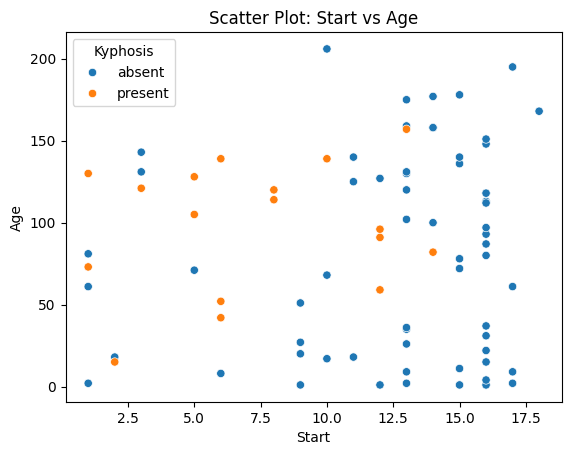

In [14]:
sns.scatterplot(data=kyph, x='Start', y='Age', hue='Kyphosis')
plt.title('Scatter Plot: Start vs Age')
plt.show()

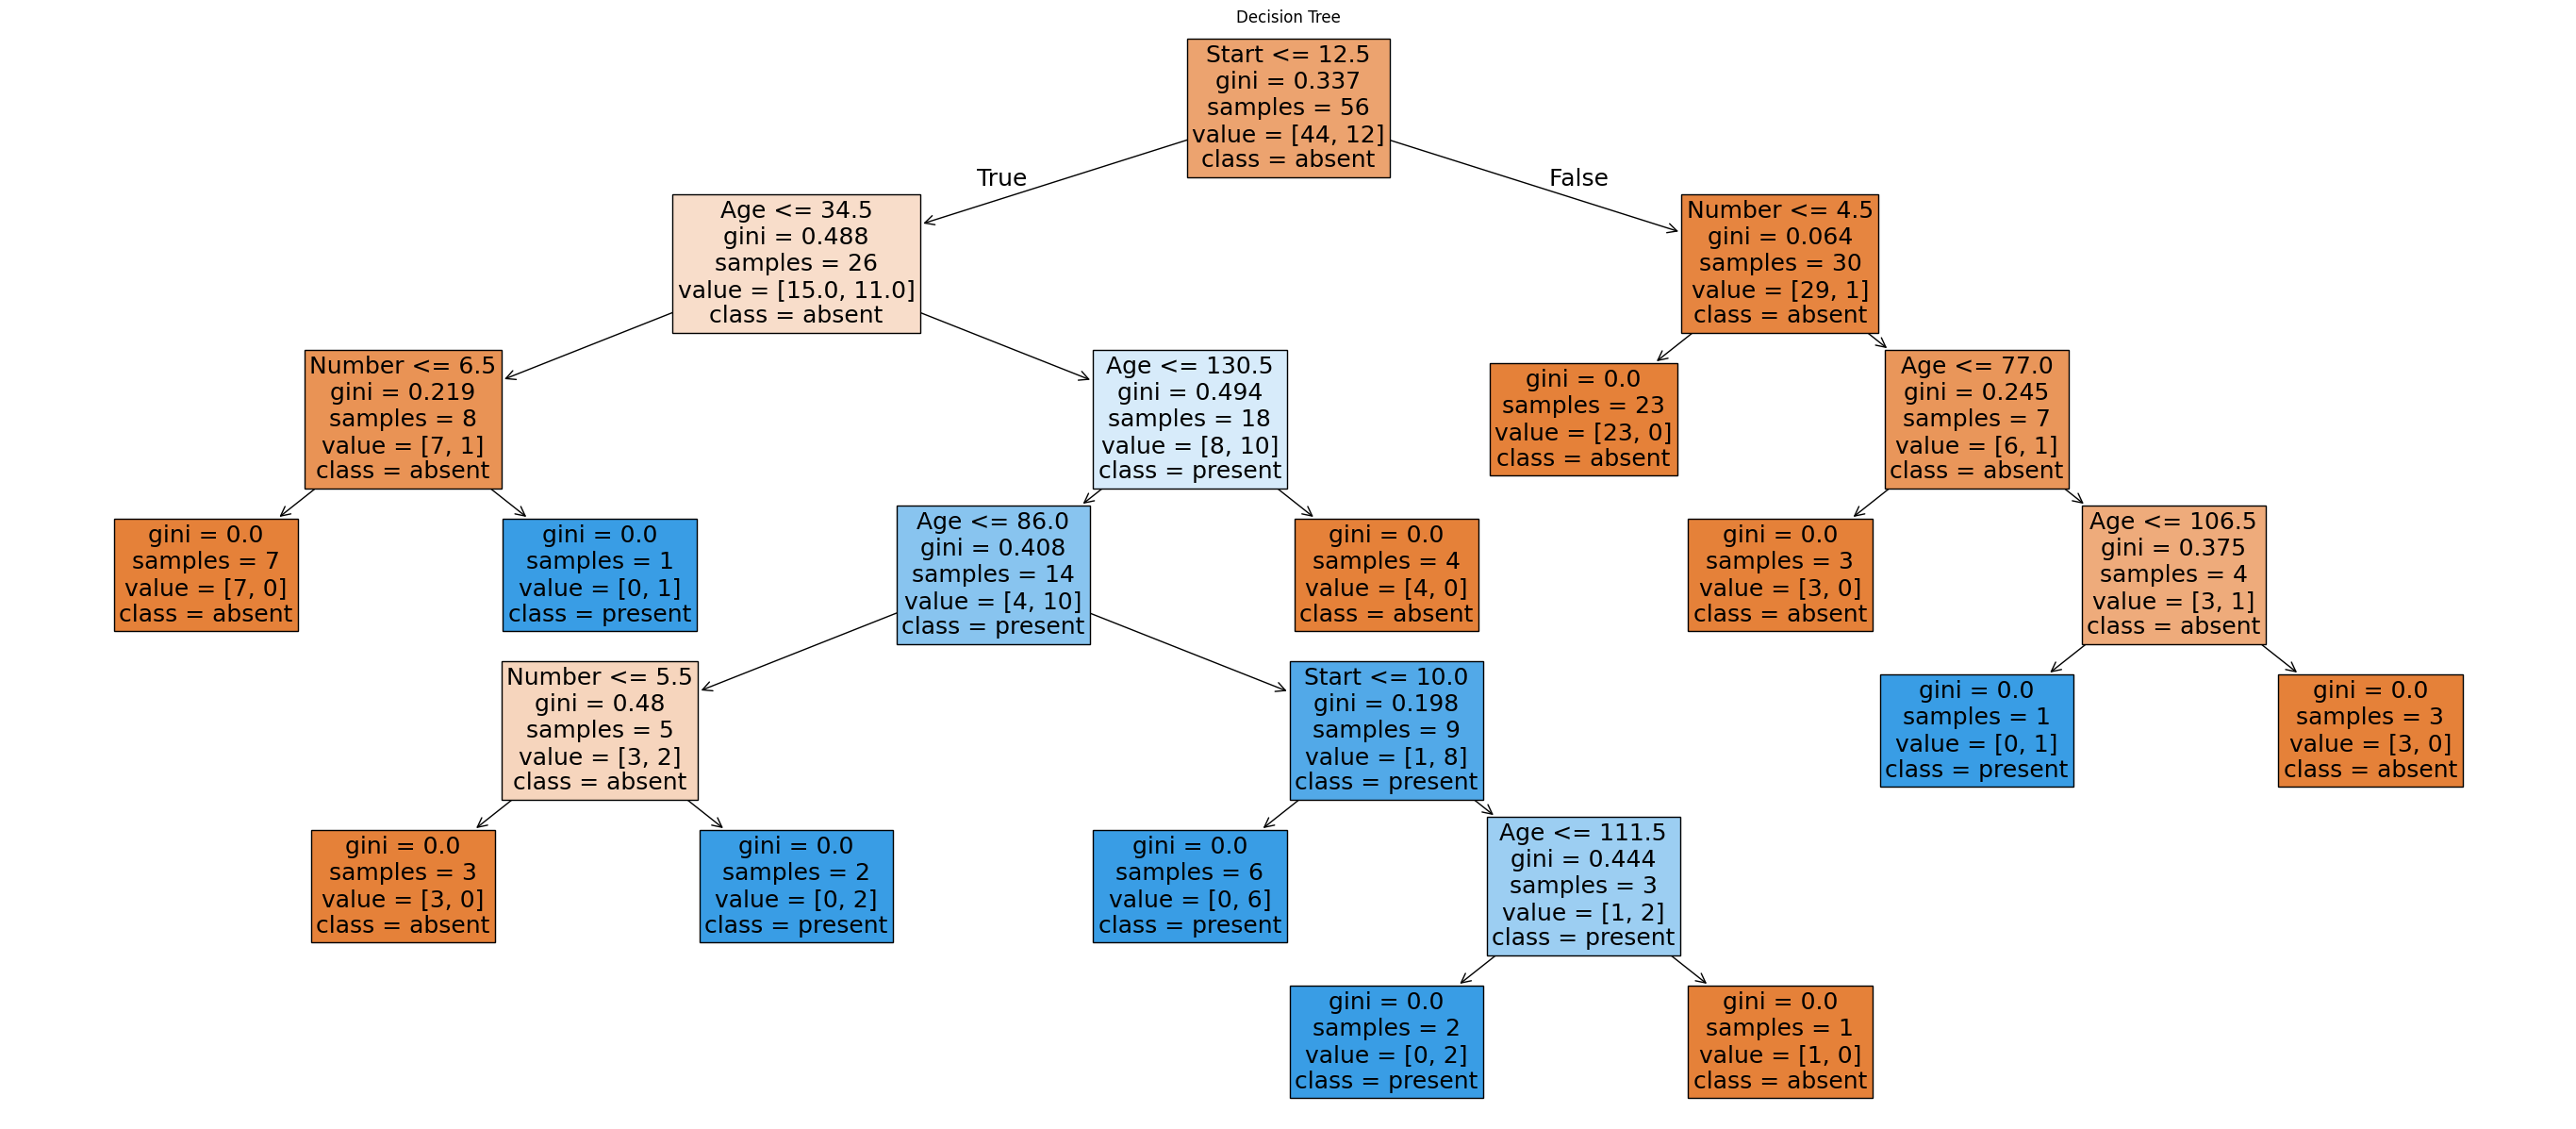

In [39]:
dtc = DecisionTreeClassifier(random_state=26)
dtc.fit(X_train, y_train)
plt.figure(figsize=(35,15))
plot_tree(dtc, feature_names=list(X.columns), class_names=['absent', 'present'], filled=True, fontsize=18)
plt.title("Decision Tree")
plt.show()

# 

In [40]:
y_pred = dtc.predict(X_test)
print("Acc:", accuracy_score(y_test, y_pred))
y_pred_prob = dtc.predict_proba(X_test)
print("LogLoss:", log_loss(y_test, y_pred_prob))

Acc: 0.68
LogLoss: 11.533969084517489


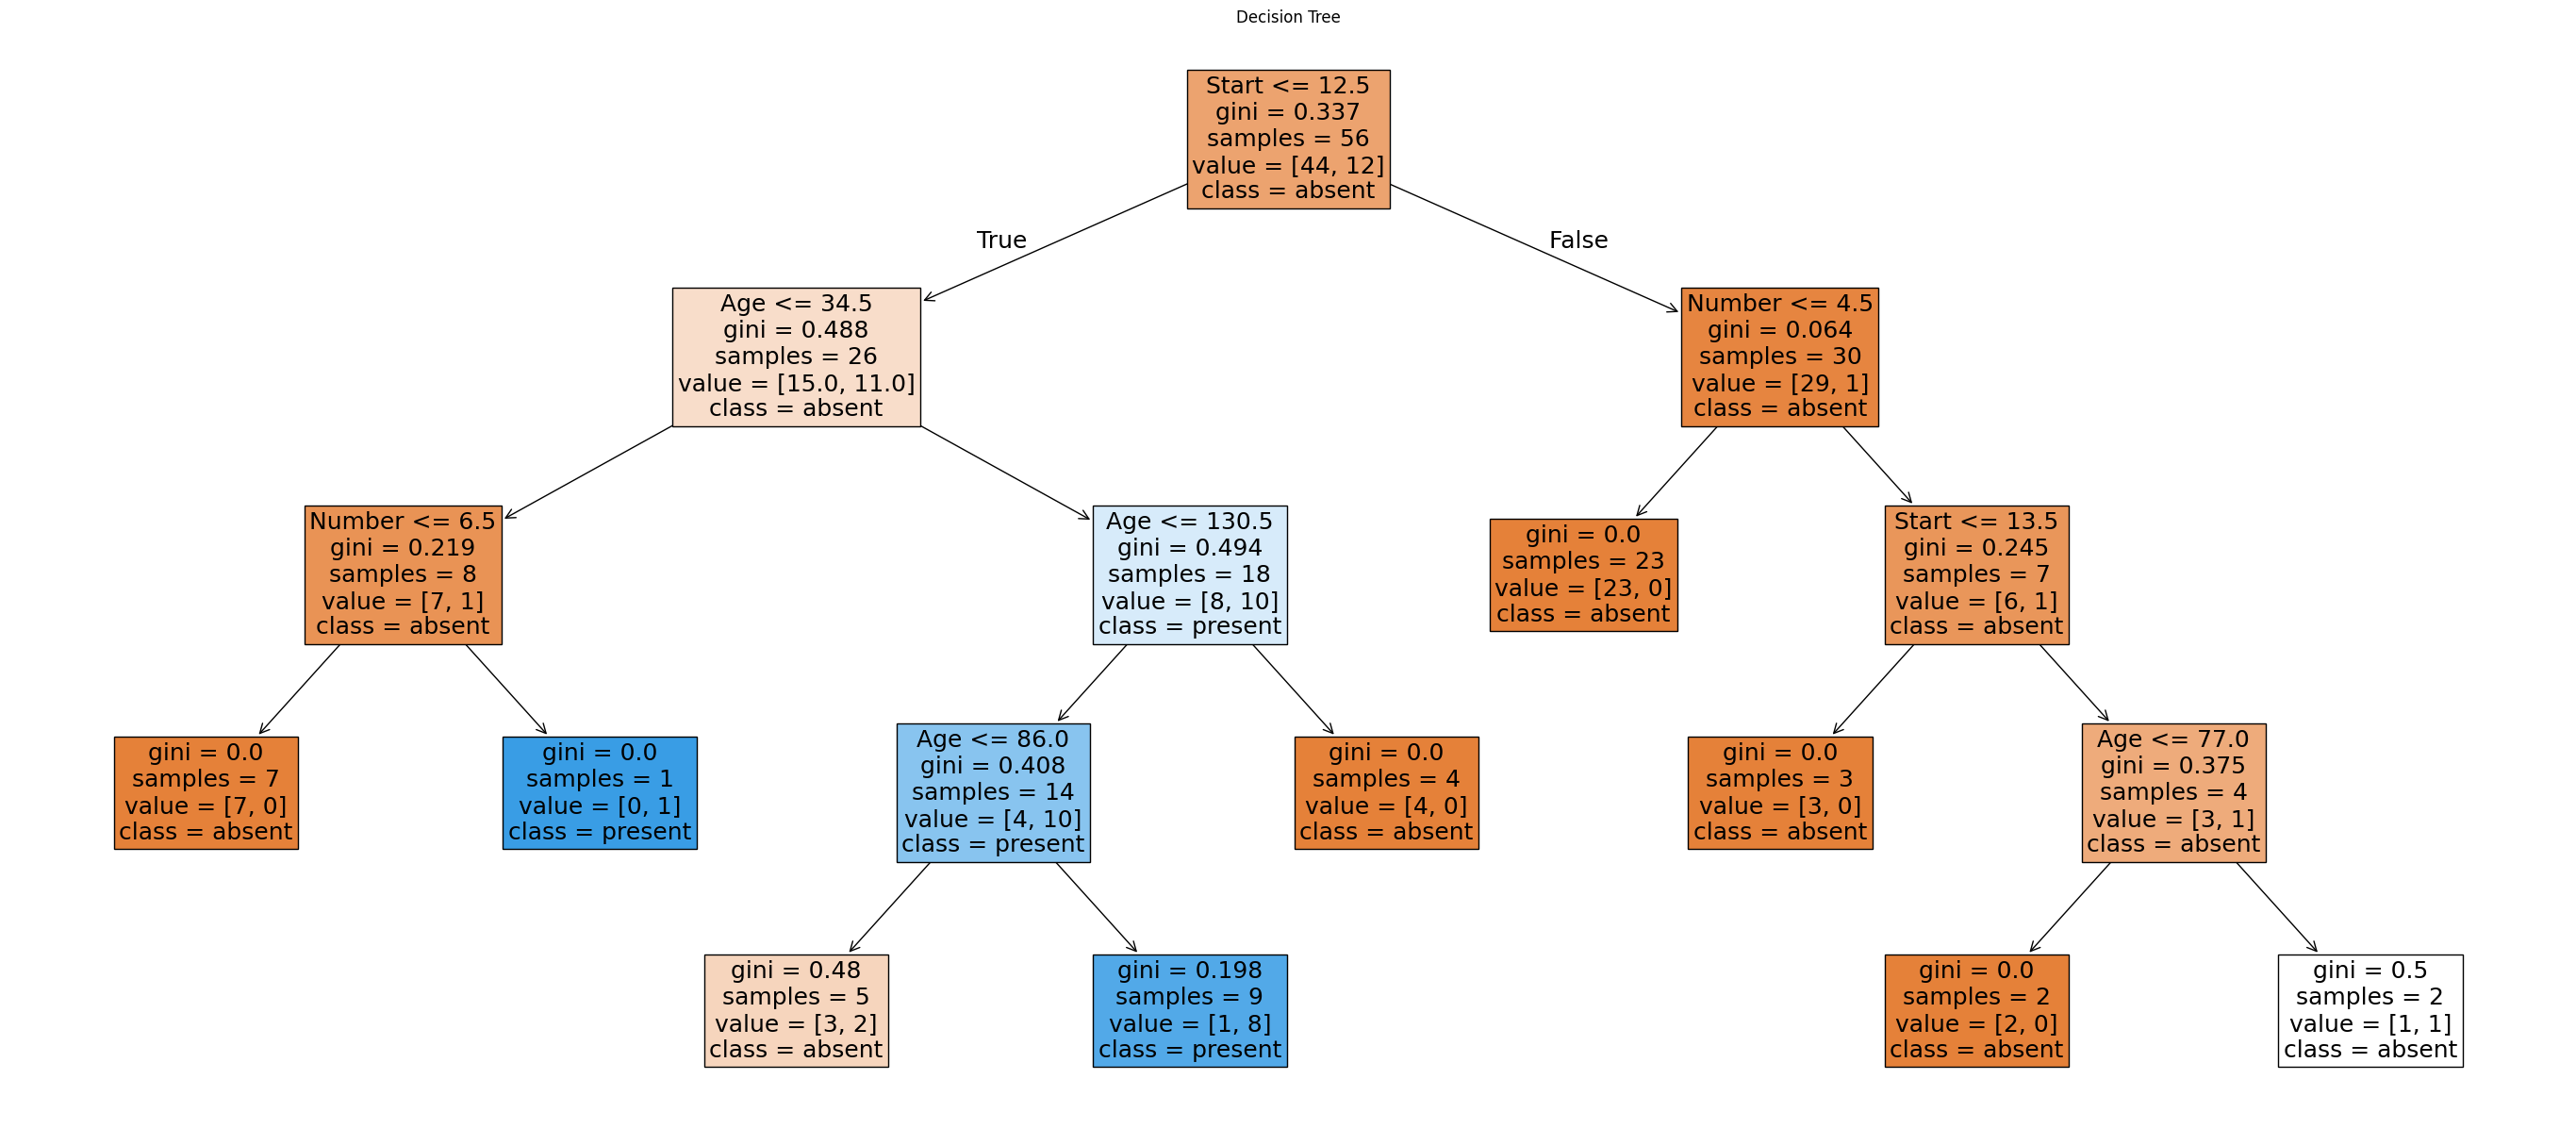

In [36]:
# prooning the tree
dtc = DecisionTreeClassifier(random_state=26, max_depth=4)
dtc.fit(X_train, y_train)
plt.figure(figsize=(35,15))
plot_tree(dtc, feature_names=list(X.columns), class_names=['absent', 'present'], filled=True, fontsize=18)
plt.title("Decision Tree")
plt.show()

In [37]:
y_pred = dtc.predict(X_test)
print("Acc:", accuracy_score(y_test, y_pred))
y_pred_prob = dtc.predict_proba(X_test)
print("LogLoss:", log_loss(y_test, y_pred_prob))


Acc: 0.76
LogLoss: 4.582748472683514


### depths

In [50]:
depths=[1,2,3,4,5,6]
scores=[]

for d in depths:
    dtc = DecisionTreeClassifier(random_state=26, max_depth=d)
    dtc.fit(X_train, y_train)
    y_pred = dtc.predict(X_test)
    y_pred_prob = dtc.predict_proba(X_test)
    scores.append([d,accuracy_score(y_test, y_pred), log_loss(y_test, y_pred_prob)])
    
df_scores = pd.DataFrame(scores, columns=['D','Accuracy', 'log_loss' ])
df_scores.sort_values(['log_loss'], ascending=True).head()

# Long term thinking LogLoss would be considerable than accuracy

,D,Accuracy,log_loss
0,1,0.80,0.404030
1,2,0.84,1.668450
2,3,0.76,4.525502
3,4,0.76,4.582748
5,6,0.68,11.533969


### sample splits

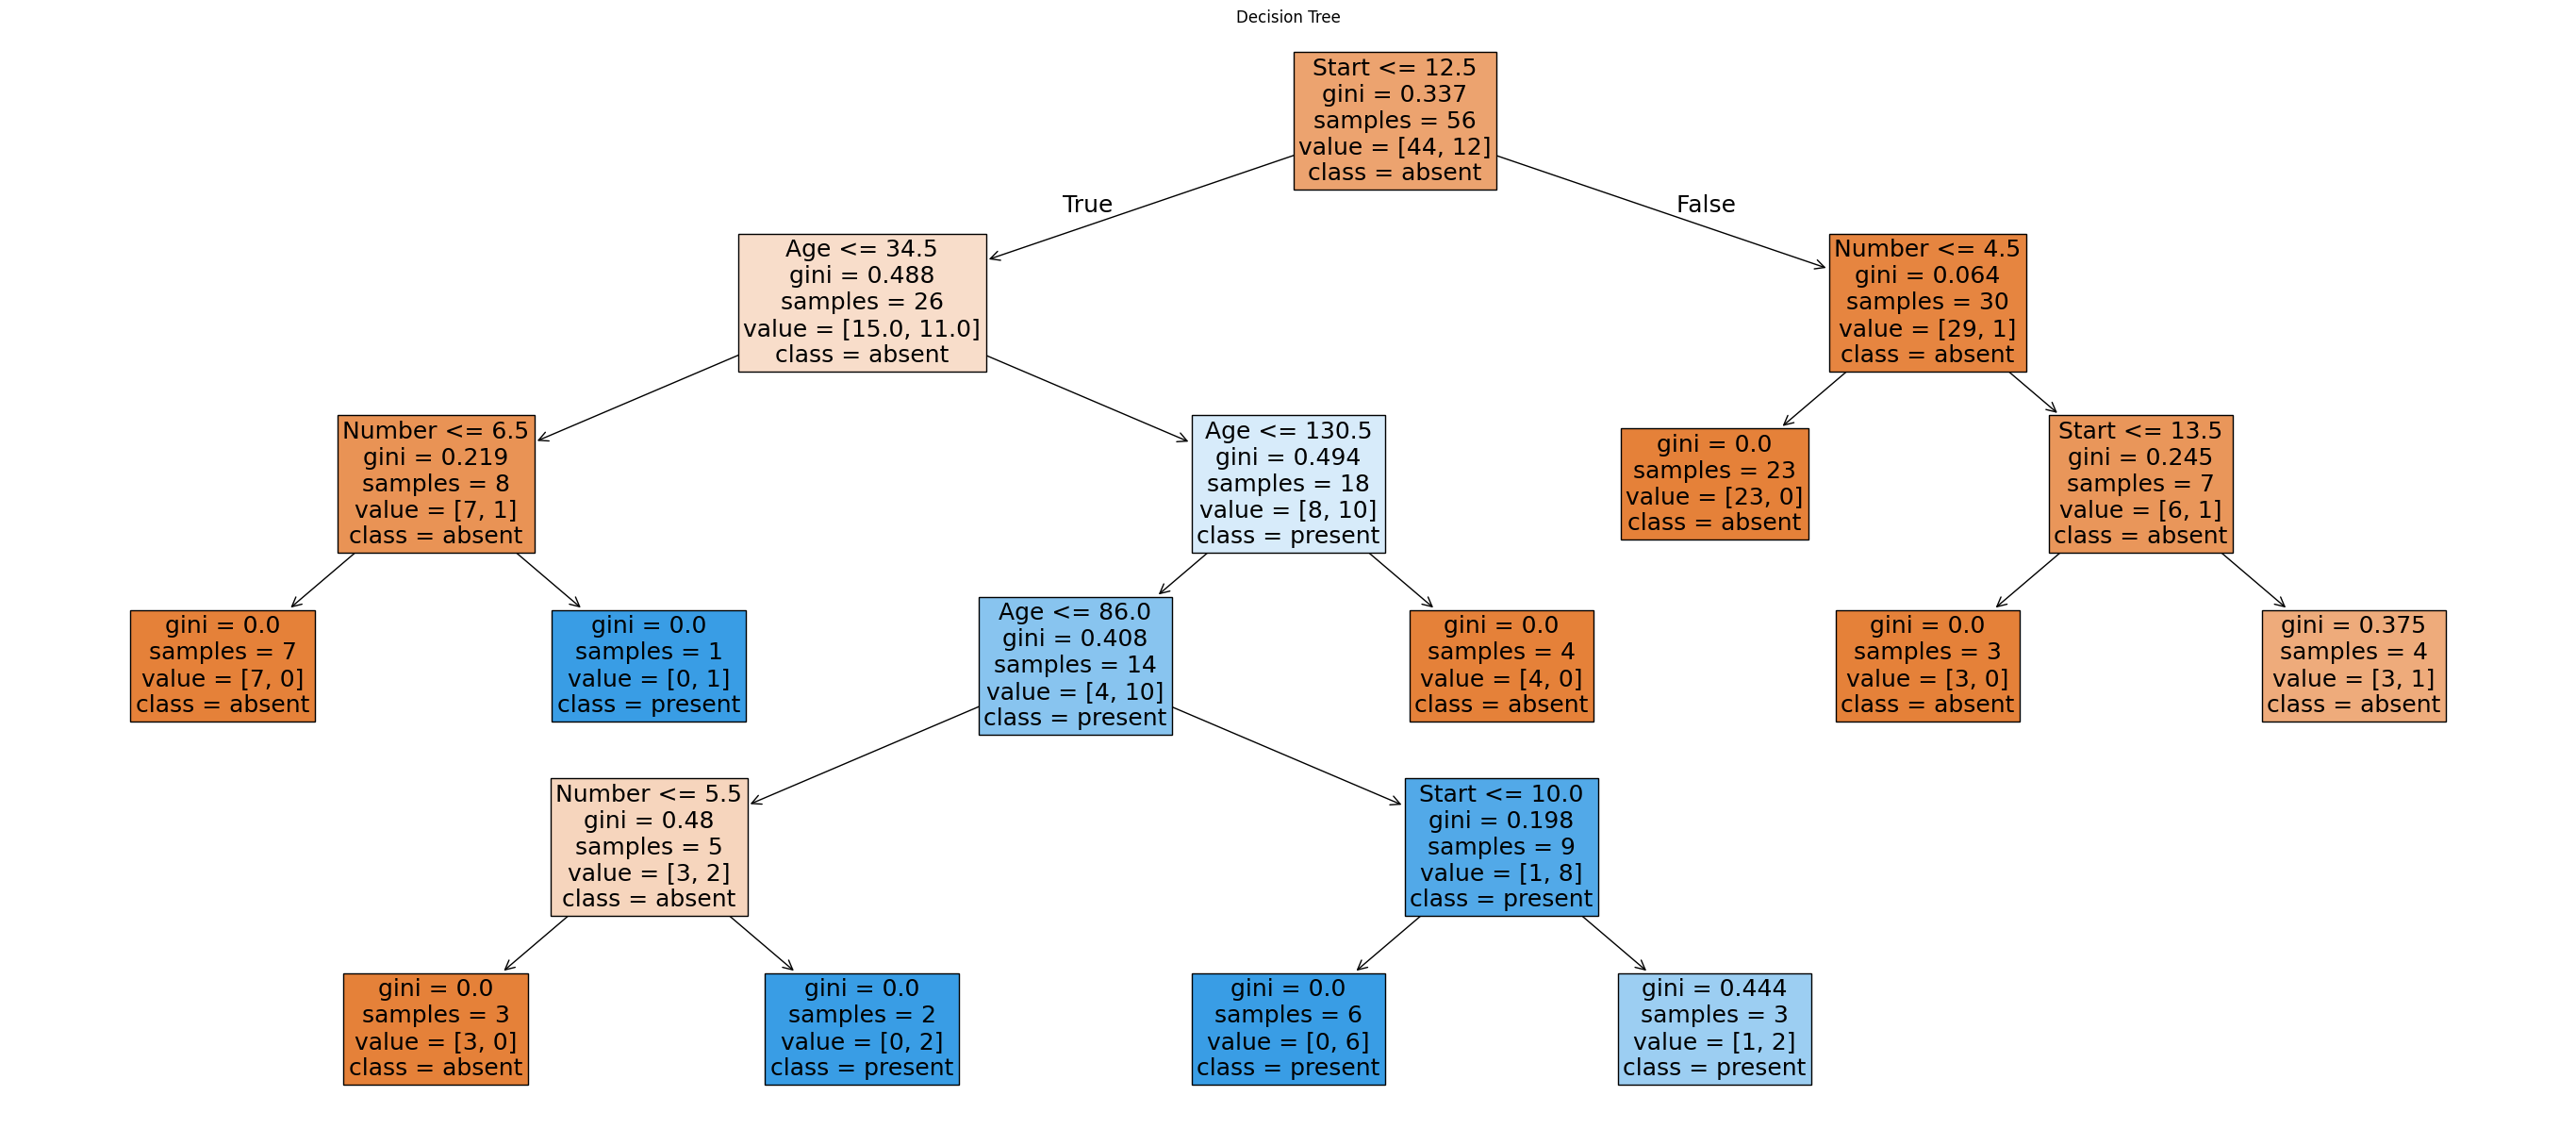

In [57]:
dtc = DecisionTreeClassifier(random_state=26, min_samples_split=5)
dtc.fit(X_train, y_train)
plt.figure(figsize=(35,15))
plot_tree(dtc, feature_names=list(X.columns), class_names=['absent', 'present'], filled=True, fontsize=18)
plt.title("Decision Tree")
plt.show()

In [48]:
splits=[2,5,10,20,30]  # by default 2
scores=[]

for s in splits:
    dtc = DecisionTreeClassifier(random_state=26, min_samples_split=s)
    dtc.fit(X_train, y_train)
    y_pred = dtc.predict(X_test)
    y_pred_prob = dtc.predict_proba(X_test)
    scores.append([s, accuracy_score(y_test, y_pred), log_loss(y_test, y_pred_prob)])
    
df_scores = pd.DataFrame(scores, columns=['S','Accuracy', 'log_loss' ])
df_scores.sort_values(['log_loss'], ascending=True).head()

# either 2 child prints or no child, single child will not be print even if min_sample satisfies

,S,Accuracy,log_loss
3,20,0.84,1.668450
4,30,0.80,1.714052
2,10,0.76,4.562643
1,5,0.72,8.717436
0,2,0.68,11.533969


### min Sample Leaf 

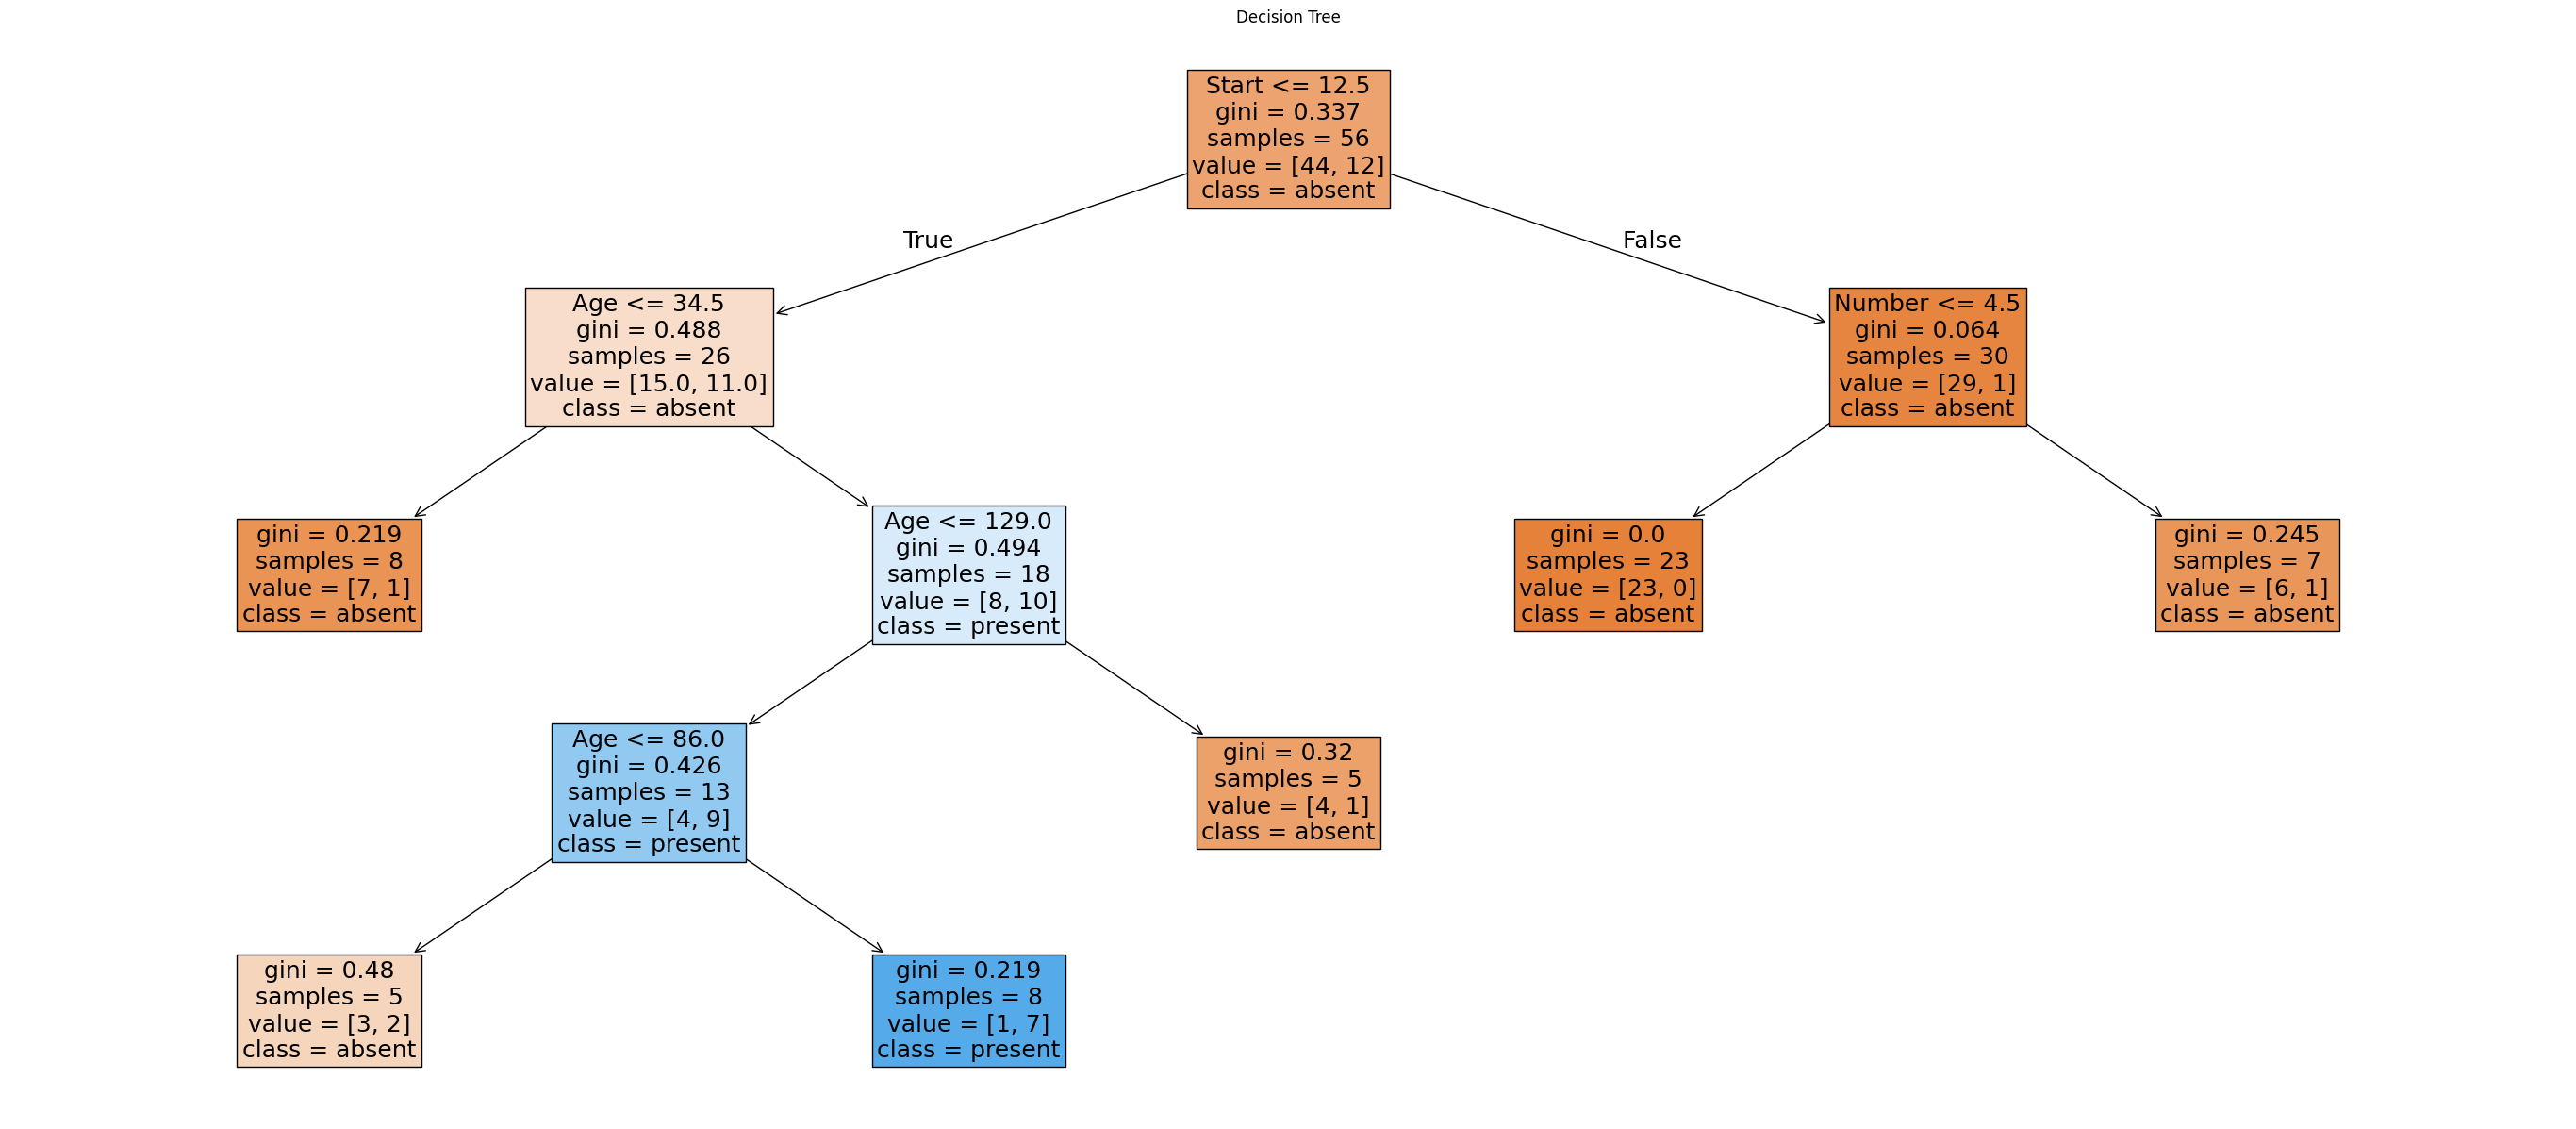

In [63]:
dtc = DecisionTreeClassifier(random_state=26, min_samples_leaf=5)
dtc.fit(X_train, y_train)
plt.figure(figsize=(35,15))
plot_tree(dtc, feature_names=list(X.columns), class_names=['absent', 'present'], filled=True, fontsize=18)
plt.title("Decision Tree")
plt.show()
# leaves with samples more than or equal to 5 will be printed
# if the one leaf is less than 5 then the other neighbor leaf should also be deleted either it's greater than 5 or not. 

In [51]:
leaves=[1,5,8,10,20]  # by default 1
scores=[]

for l in leaves:
    dtc = DecisionTreeClassifier(random_state=26, min_samples_leaf=l)
    dtc.fit(X_train, y_train)
    y_pred = dtc.predict(X_test)
    y_pred_prob = dtc.predict_proba(X_test)
    scores.append([l, accuracy_score(y_test, y_pred), log_loss(y_test, y_pred_prob)])
    
df_scores = pd.DataFrame(scores, columns=['L','Accuracy', 'log_loss' ])
df_scores.sort_values(['log_loss'], ascending=True).head()

,L,Accuracy,log_loss
2,8,0.80,0.358709
4,20,0.80,0.404030
3,10,0.84,1.703706
1,5,0.76,1.803195
0,1,0.68,11.533969


## All in one

In [53]:
depths = np.arange(1,7)
splits = np.arange(2,25)
leaves=np.arange(1,25)
scores=[]

for d in depths:
    for s in splits:
        for l in leaves:
            dtc = DecisionTreeClassifier(random_state=26, max_depth=d, min_samples_split=s, min_samples_leaf=l)
            
            dtc.fit(X_train, y_train)
            y_pred = dtc.predict(X_test)
            y_pred_prob = dtc.predict_proba(X_test)
            
            scores.append([d, s, l, accuracy_score(y_test, y_pred), log_loss(y_test, y_pred_prob)])
    
df_scores = pd.DataFrame(scores, columns=['Depth', 'Splits', 'Leaves', 'Accuracy', 'log_loss' ])
df_scores.sort_values(['log_loss'], ascending=True).head()

,Depth,Splits,Leaves,Accuracy,log_loss
2095,4,20,8,0.84,0.327948
2071,4,19,8,0.84,0.327948
2119,4,21,8,0.84,0.327948
2143,4,22,8,0.84,0.327948
2167,4,23,8,0.84,0.327948


# Best Tree

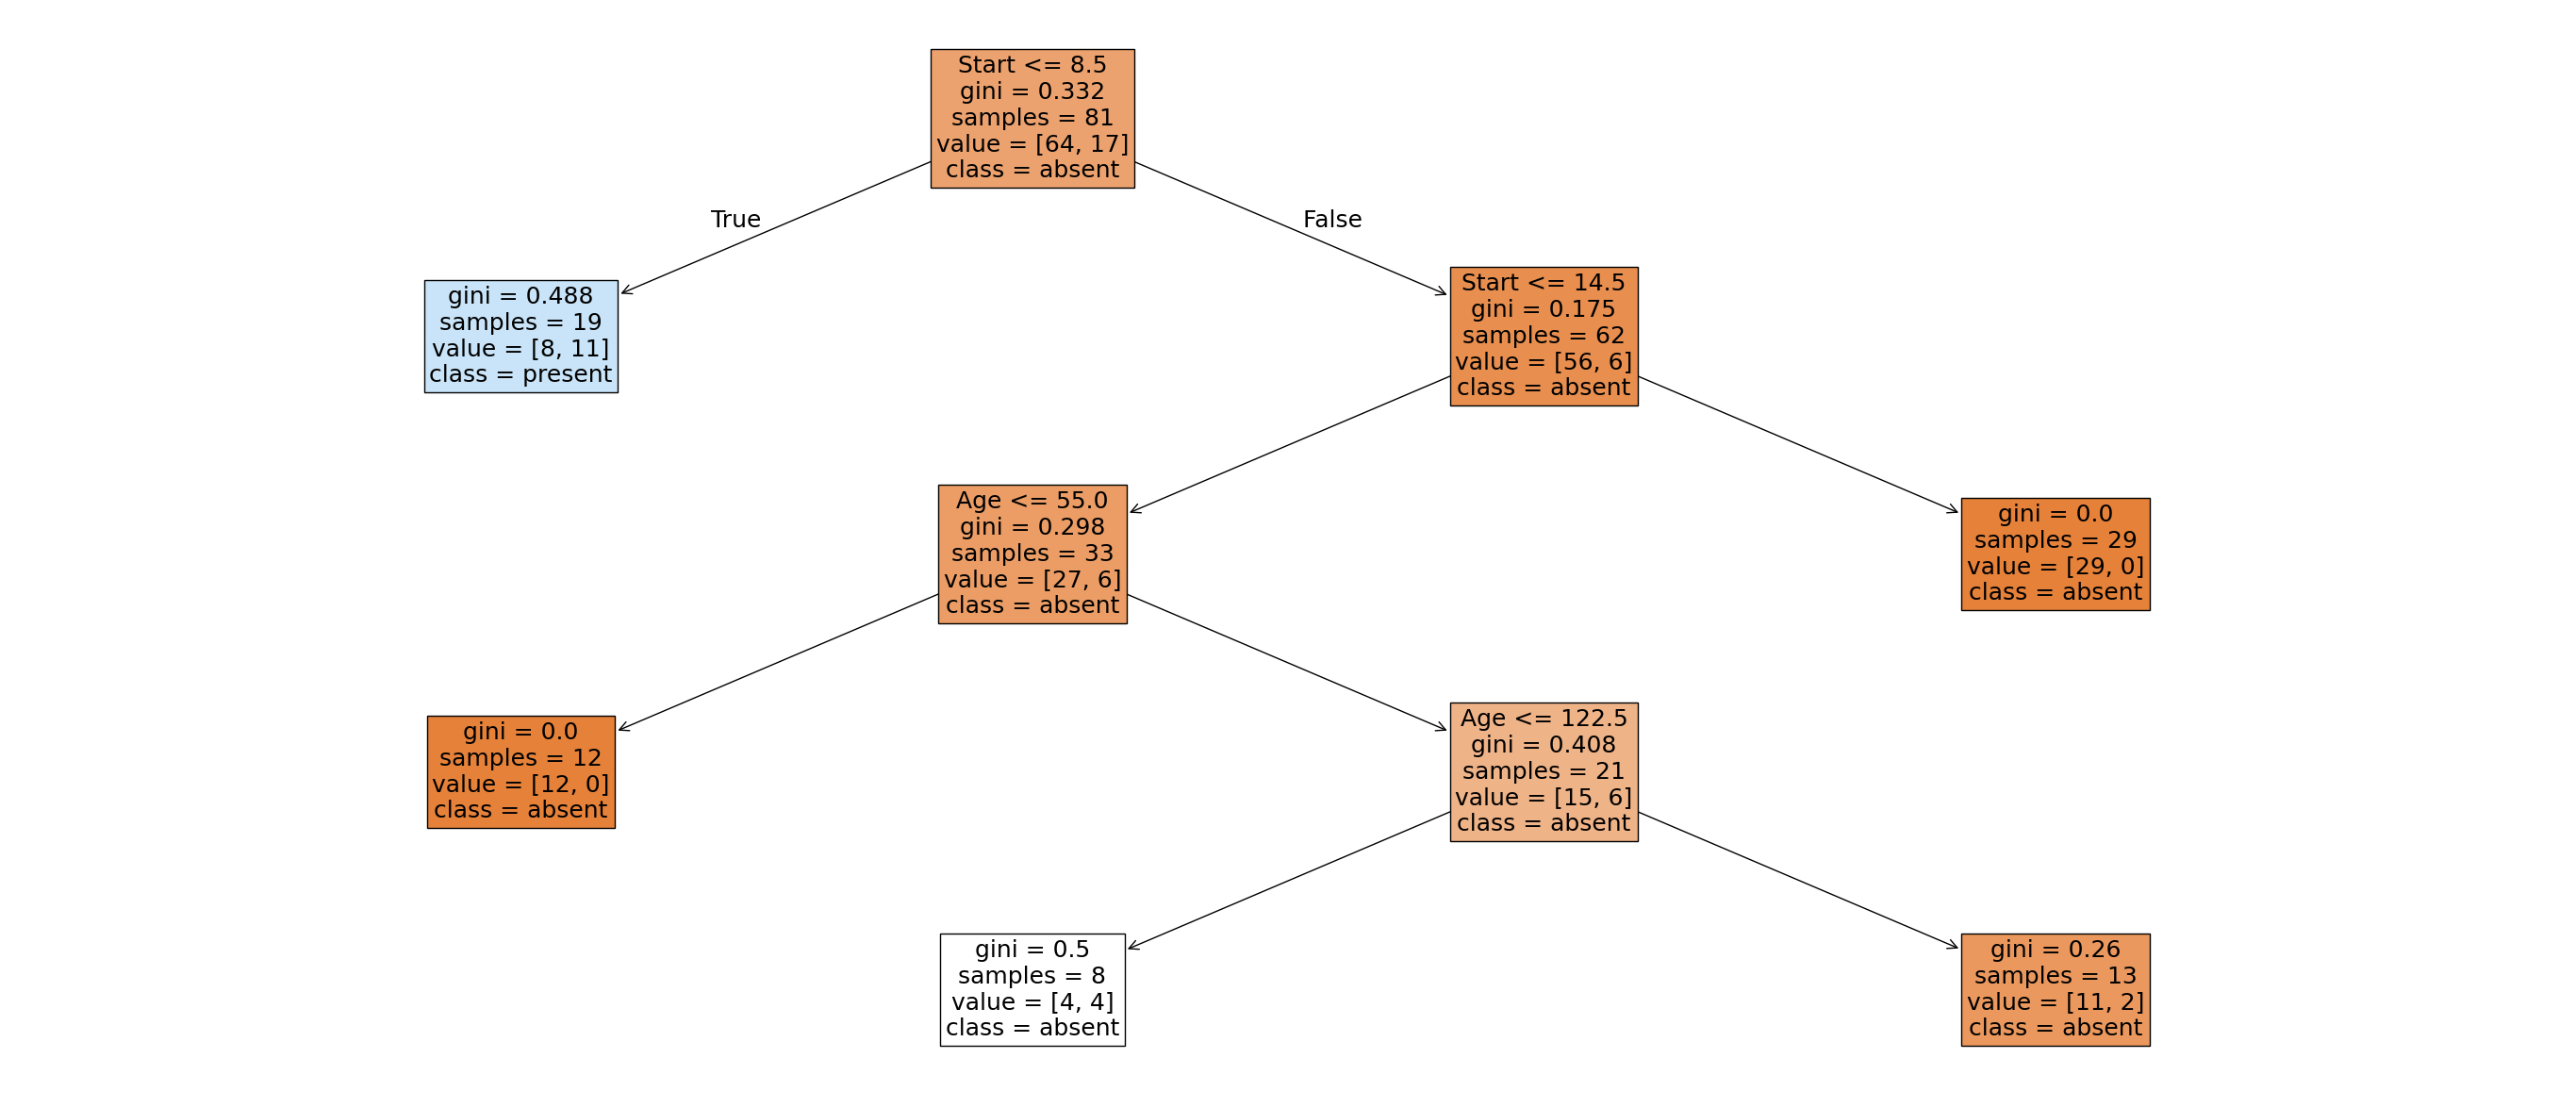

In [64]:
bm =  DecisionTreeClassifier(random_state=26, max_depth=4, min_samples_split=20, min_samples_leaf=8)
bm.fit(X,y)
plt.figure(figsize=(35,15))
plot_tree(bm, feature_names=list(X.columns), class_names=['absent', 'present'], filled=True, fontsize=18)
plt.show()

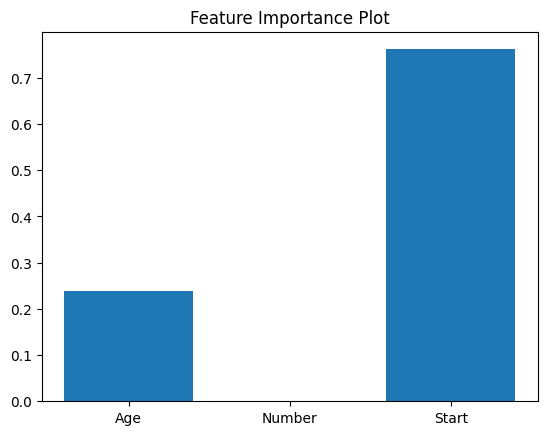

In [65]:
df_imp = pd.DataFrame({'feature':X.columns, 'importance':bm.feature_importances_})
plt.bar(df_imp['feature'], df_imp['importance'])
plt.title("Feature Importance Plot")
plt.show()

### Gini

In [24]:
value=[44,12]
f1, f2 = 44/(44+12), 12/(12+44)
gini = f1*(1-f1) + f2*(1-f2)
gini

0.33673469387755106

In [25]:
value=[44,12]
i,j=value[0], value[1]
t=value[0]+value[1]
f1, f2 = i/t, j/t
gini = f1*(1-f1) + f2*(1-f2)
gini

0.33673469387755106

In [26]:
value=[50,50]
i,j=value[0], value[1]
t=value[0]+value[1]
f1, f2 = i/t, j/t
gini = f1*(1-f1) + f2*(1-f2)
gini

0.5

In [27]:
value=[40,60]
i,j=value[0], value[1]
t=value[0]+value[1]
f1, f2 = i/t, j/t
gini = f1*(1-f1) + f2*(1-f2)
gini

0.48

In [ ]:
# For Understanding Only

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 9))
sns.scatterplot(data=kyph, x='Start', y='Age', hue='Kyphosis', 
                palette={'absent': 'green', 'present': 'red'}, s=100, alpha=0.8)

# --- START SPLITS (Vertical) ---
plt.axvline(x=12.5, color='blue', linestyle='--', linewidth=2, label='Start <= 12.5 (Root)')
plt.axvline(x=10.0, color='blue', linestyle='--', alpha=0.6, label='Start <= 10.0')

# --- AGE SPLITS (Horizontal) ---
# Main Age split from your tree
plt.axhline(y=111.5, color='orange', linestyle='--', linewidth=2, label='Age <= 111.5')
# Lower Age splits seen in your tree nodes
plt.axhline(y=34.5, color='orange', linestyle=':', alpha=0.7,linewidth=2, label='Age <= 34.5')
plt.axhline(y=77.0, color='orange', linestyle=':', alpha=0.7,linewidth=2,label='Age <= 77.0')
plt.axhline(y=86.0, color='orange', linestyle=':', alpha=0.7,linewidth=2, label='Age <= 86.0')
plt.axhline(y=106.5, color='orange', linestyle=':', alpha=0.7,linewidth=2, label='Age <= 86.0')

# --- NUMBER SPLITS (Dashed Grey) ---
# Since Number isn't an axis, these vertical lines represent the threshold 
# logic for the 'Number' feature found in your tree leaves.
plt.axvline(x=4.5, color='grey', linestyle='-.', alpha=0.5, label='Number Split (Logic: 4.5)')
plt.axvline(x=5.5, color='grey', linestyle='-.', alpha=0.5, label='Number Split (Logic: 5.5)')

# Formatting to make it readable
plt.title('Complete Decision Tree Boundaries\n(Mapped from all Tree Nodes)', fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.xlabel('Start (Starting Vertebrae)', fontsize=12)
plt.ylabel('Age (Months)', fontsize=12)
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()